# 02 - Exploratory Data Analysis
**Project:** E-Commerce Sales & Customer Analytics

This notebook explores the cleaned dataset to answer concrete business questions about
sales, profitability, customers, products, and the discount-profit relationship. Every
chart here is tied to a specific question - no chart exists purely for decoration.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/cleaned/ecommerce_cleaned.csv', parse_dates=['Order_Date'])
df.shape


(41262, 24)

## 1. Sales overview

In [2]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
avg_order_value = total_sales / total_orders
overall_margin = total_profit / total_sales

print(f"Total Sales:        Rs {total_sales:,.0f}")
print(f"Total Profit:       Rs {total_profit:,.0f}")
print(f"Overall Margin:     {overall_margin:.2%}")
print(f"Total Orders:       {total_orders:,}")
print(f"Total Customers:    {total_customers:,}")
print(f"Avg Order Value:    Rs {avg_order_value:,.0f}")


Total Sales:        Rs 715,833,822
Total Profit:       Rs 37,911,637
Overall Margin:     5.30%
Total Orders:       41,262
Total Customers:    3,923
Avg Order Value:    Rs 17,349


### Monthly sales & profit trend
**Question: How does revenue and profit move across the two years, and is there seasonality?**

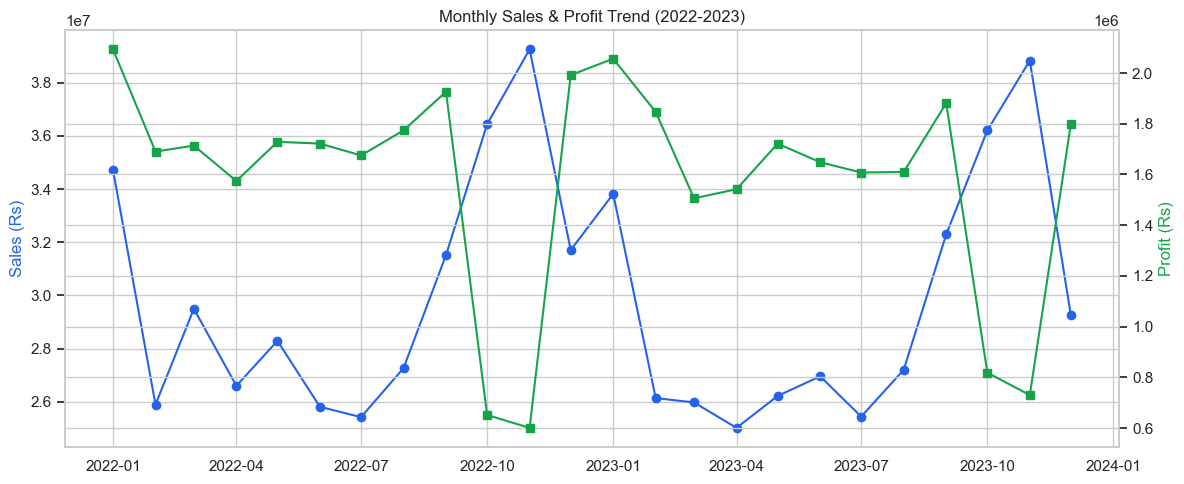

In [3]:
monthly = df.groupby(pd.Grouper(key='Order_Date', freq='MS')).agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(monthly['Order_Date'], monthly['Sales'], marker='o', color='#2563eb', label='Sales')
ax1.set_ylabel('Sales (Rs)', color='#2563eb')
ax2 = ax1.twinx()
ax2.plot(monthly['Order_Date'], monthly['Profit'], marker='s', color='#16a34a', label='Profit')
ax2.set_ylabel('Profit (Rs)', color='#16a34a')
ax1.set_title('Monthly Sales & Profit Trend (2022-2023)')
fig.tight_layout()
plt.savefig('../reports/chart_monthly_trend.png', bbox_inches='tight')
plt.show()


In [4]:
# Yearly comparison and growth
yearly = df.groupby('Year').agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order_ID','nunique')).reset_index()
yearly['Sales_Growth_%'] = yearly['Sales'].pct_change() * 100
yearly


,Year,Sales,Profit,Orders,Sales_Growth_%
0,2022,3.624470e+08,19142395.26,20605,NaN
1,2023,3.533868e+08,18769241.31,20657,-2.499743


### Sales by category, sub-category and region
**Question: Which parts of the business generate the most revenue?**

C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\53341689.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='Blues_r')


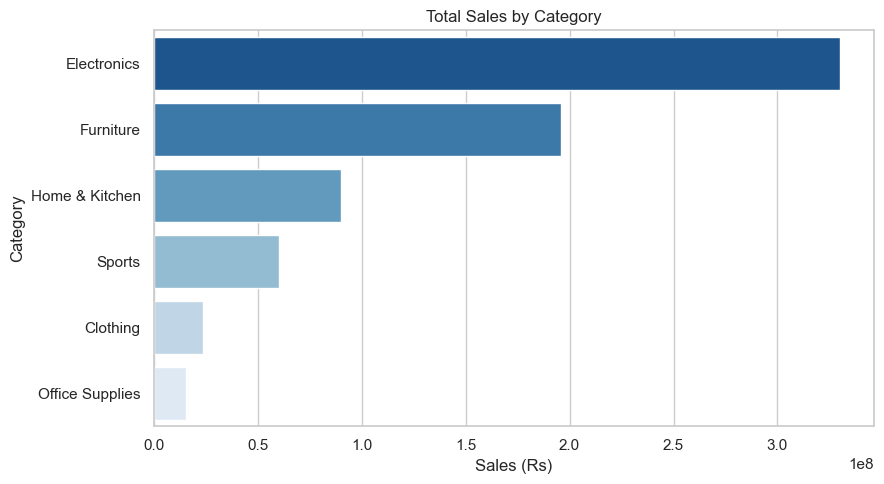

Category
Electronics        3.299499e+08
Furniture          1.959941e+08
Home & Kitchen     9.006799e+07
Sports             6.044748e+07
Clothing           2.382781e+07
Office Supplies    1.554654e+07
Name: Sales, dtype: float64

In [5]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='Blues_r')
plt.title('Total Sales by Category')
plt.xlabel('Sales (Rs)')
plt.tight_layout()
plt.savefig('../reports/chart_sales_by_category.png', bbox_inches='tight')
plt.show()
cat_sales


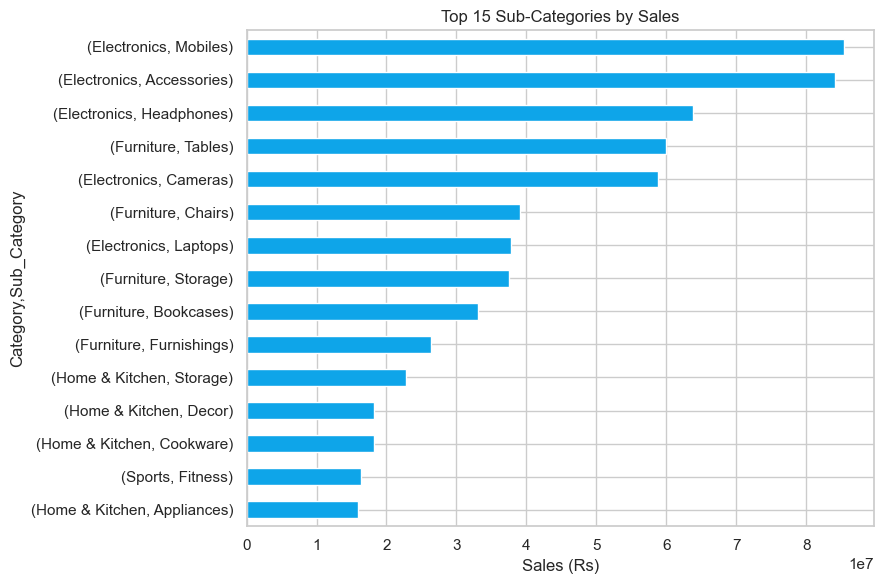

In [6]:
subcat_sales = df.groupby(['Category','Sub_Category'])['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
subcat_sales.sort_values().plot(kind='barh', color='#0ea5e9')
plt.title('Top 15 Sub-Categories by Sales')
plt.xlabel('Sales (Rs)')
plt.tight_layout()
plt.savefig('../reports/chart_top_subcategories.png', bbox_inches='tight')
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\4098035929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='viridis')


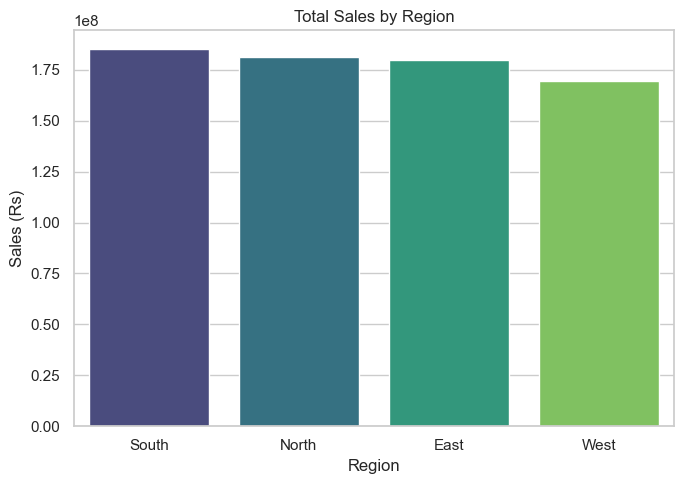

Region
South    1.850997e+08
North    1.813151e+08
East     1.799332e+08
West     1.694858e+08
Name: Sales, dtype: float64

In [7]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='viridis')
plt.title('Total Sales by Region')
plt.ylabel('Sales (Rs)')
plt.tight_layout()
plt.savefig('../reports/chart_sales_by_region.png', bbox_inches='tight')
plt.show()
region_sales


In [8]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 states by sales:\n", state_sales)
print("\nTop 10 cities by sales:\n", city_sales)


Top 10 states by sales:
 State
Punjab           6.334122e+07
Tamil Nadu       6.256487e+07
Karnataka        6.198898e+07
Bihar            6.080281e+07
Telangana        6.054584e+07
Maharashtra      5.994843e+07
Odisha           5.982701e+07
West Bengal      5.930341e+07
Delhi            5.909982e+07
Uttar Pradesh    5.887403e+07
Name: Sales, dtype: float64

Top 10 cities by sales:
 City
Mangaluru     2.221150e+07
Coimbatore    2.178976e+07
Ludhiana      2.177686e+07
Mysuru        2.058379e+07
Amritsar      2.027881e+07
Gaya          2.022110e+07
Chennai       2.005414e+07
Rourkela      2.003764e+07
Nagpur        1.999675e+07
Warangal      1.988736e+07
Name: Sales, dtype: float64


## 2. Profitability

C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\1610471672.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_cat.values, y=profit_by_cat.index, ax=axes[0], palette='Greens_r')
C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\1610471672.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=margin_by_cat.values*100, y=margin_by_cat.index, ax=axes[1], palette='Oranges_r')


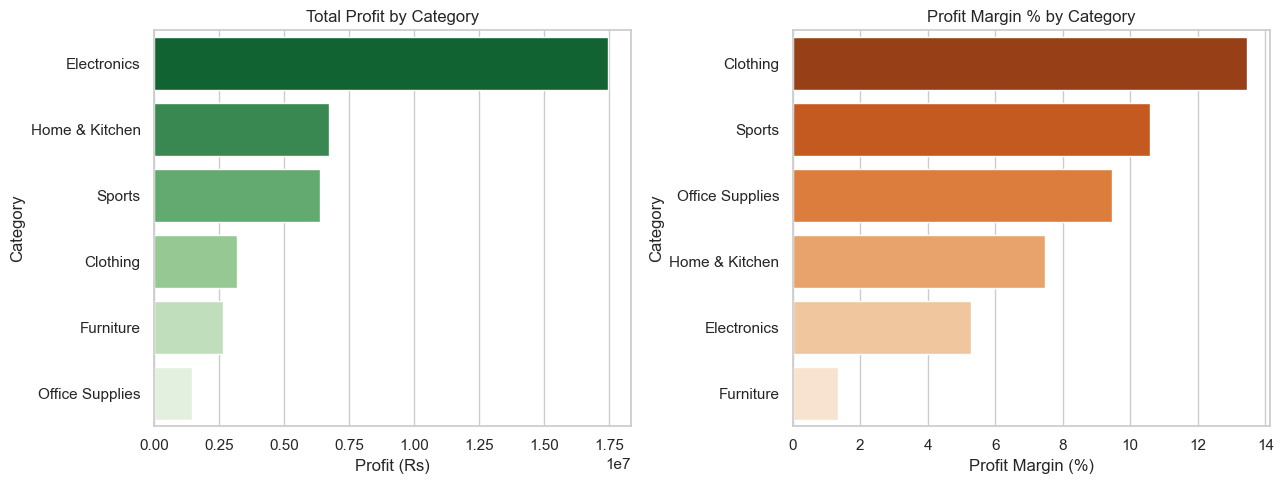

In [9]:
profit_by_cat = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
margin_by_cat = (df.groupby('Category')['Profit'].sum() / df.groupby('Category')['Sales'].sum()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.barplot(x=profit_by_cat.values, y=profit_by_cat.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Total Profit by Category')
axes[0].set_xlabel('Profit (Rs)')

sns.barplot(x=margin_by_cat.values*100, y=margin_by_cat.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Profit Margin % by Category')
axes[1].set_xlabel('Profit Margin (%)')
plt.tight_layout()
plt.savefig('../reports/chart_profit_by_category.png', bbox_inches='tight')
plt.show()


In [10]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_margin = (df.groupby('Region')['Profit'].sum() / df.groupby('Region')['Sales'].sum())
print(region_profit)
print()
print((region_margin*100).round(2).astype(str) + '%')


Region
East     9856607.55
South    9641089.45
North    9277565.56
West     9136374.01
Name: Profit, dtype: float64

Region
East     5.48%
North    5.12%
South    5.21%
West     5.39%
dtype: object


**Question: Which specific products are losing money?**

In [11]:
product_profit = df.groupby(['Product_ID','Product_Name','Category'])['Profit'].sum().reset_index()
loss_making = product_profit[product_profit['Profit'] < 0].sort_values('Profit')
print(f"{len(loss_making)} products are net loss-making out of {product_profit['Product_ID'].nunique()} total products")
loss_making.head(15)


2 products are net loss-making out of 335 total products


,Product_ID,Product_Name,Category,Profit
79,PROD-00080,Tables Professor Max,Furniture,-4064.41
63,PROD-00064,Chairs Political Max,Furniture,-3850.86


## 3. Customers

In [12]:
cust_orders = df.groupby('Customer_ID')['Order_ID'].nunique()
cust_revenue = df.groupby('Customer_ID')['Sales'].sum()

print("Total unique customers:", df['Customer_ID'].nunique())
print("Avg orders per customer:", cust_orders.mean().round(2))
print("Avg revenue per customer: Rs", cust_revenue.mean().round(0))

repeat_customers = (cust_orders > 1).sum()
one_time_customers = (cust_orders == 1).sum()
print(f"\nRepeat customers (>1 order): {repeat_customers} ({repeat_customers/len(cust_orders):.1%})")
print(f"One-time customers: {one_time_customers} ({one_time_customers/len(cust_orders):.1%})")


Total unique customers: 3923
Avg orders per customer: 10.52
Avg revenue per customer: Rs 182471.0

Repeat customers (>1 order): 3471 (88.5%)
One-time customers: 452 (11.5%)


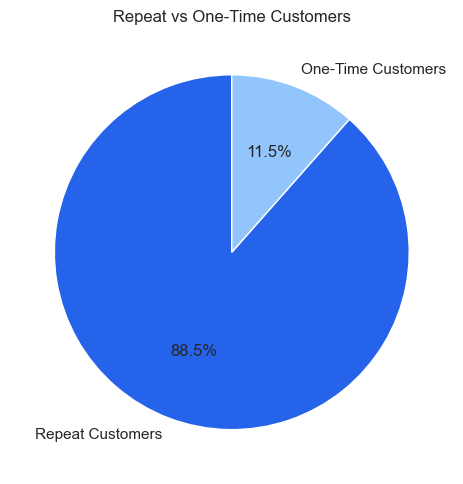

In [13]:
plt.figure(figsize=(7,5))
plt.pie([repeat_customers, one_time_customers], labels=['Repeat Customers','One-Time Customers'],
        autopct='%1.1f%%', colors=['#2563eb','#93c5fd'], startangle=90)
plt.title('Repeat vs One-Time Customers')
plt.tight_layout()
plt.savefig('../reports/chart_repeat_vs_onetime.png', bbox_inches='tight')
plt.show()


In [14]:
top_customers = df.groupby(['Customer_ID','Customer_Name'])['Sales'].sum().sort_values(ascending=False).head(10)
top_customers


Customer_ID  Customer_Name  
CUST-00197   Daniel Salinas     8911280.54
CUST-01130   James Rivers       6061278.57
CUST-03315   Melissa Santos     5957967.45
CUST-02195   Mark Warren IV     4101206.49
CUST-03068   Alexander Hunt     3683109.49
CUST-01620   Stephen Young      3445892.11
CUST-03073   Patrick Simpson    3244204.35
CUST-03109   Adam Garcia        3198444.14
CUST-02967   Candice Ramirez    3133200.54
CUST-03922   Patrick Gibson     2951683.86
Name: Sales, dtype: float64

## 4. Products

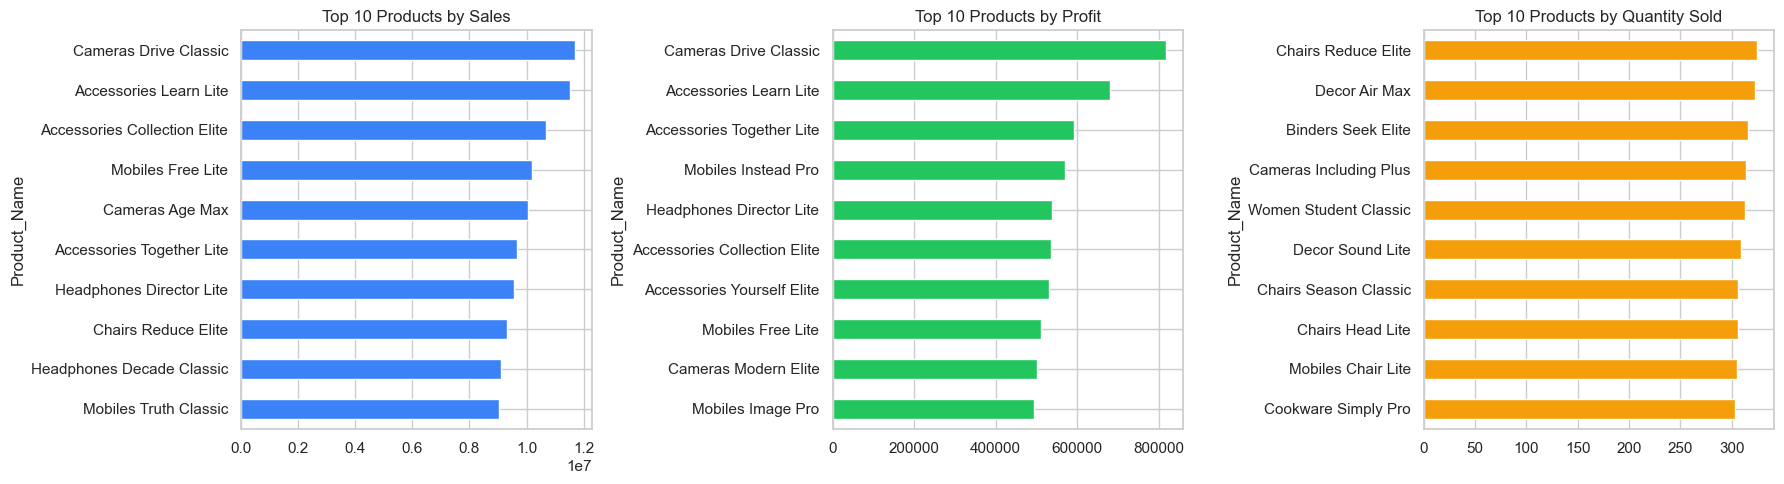

In [15]:
top_products_sales = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products_profit = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False).head(10)
top_products_qty = df.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18,5))
top_products_sales.sort_values().plot(kind='barh', ax=axes[0], color='#3b82f6')
axes[0].set_title('Top 10 Products by Sales')
top_products_profit.sort_values().plot(kind='barh', ax=axes[1], color='#22c55e')
axes[1].set_title('Top 10 Products by Profit')
top_products_qty.sort_values().plot(kind='barh', ax=axes[2], color='#f59e0b')
axes[2].set_title('Top 10 Products by Quantity Sold')
plt.tight_layout()
plt.savefig('../reports/chart_top_products.png', bbox_inches='tight')
plt.show()


## 5. Discount vs Sales vs Profit
**Question: Does discounting hurt profitability?**

In [16]:
df['Discount_Bucket'] = pd.cut(df['Discount'], bins=[-0.01,0,0.1,0.2,0.3,1.0],
                                 labels=['0%','1-10%','11-20%','21-30%','30%+'])
discount_summary = df.groupby('Discount_Bucket').agg(
    Avg_Sales=('Sales','mean'), Avg_Profit=('Profit','mean'),
    Avg_Margin=('Profit_Margin','mean'), Orders=('Order_ID','count')
)
discount_summary


C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\3953687248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_summary = df.groupby('Discount_Bucket').agg(


,Avg_Sales,Avg_Profit,Avg_Margin,Orders
Discount_Bucket,,,,
0%,19191.755212,2686.290128,0.166862,10583
1-10%,17941.144304,1291.306839,0.097349,15945
11-20%,16204.900550,-243.521160,0.011006,10530
21-30%,13956.856891,-1663.731155,-0.094005,2710
30%+,12178.879284,-2700.314685,-0.198584,1494


C:\Users\Admin\AppData\Local\Temp\ipykernel_8824\1459877501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Discount_Bucket', y='Profit_Margin', ax=axes[0], palette='coolwarm')


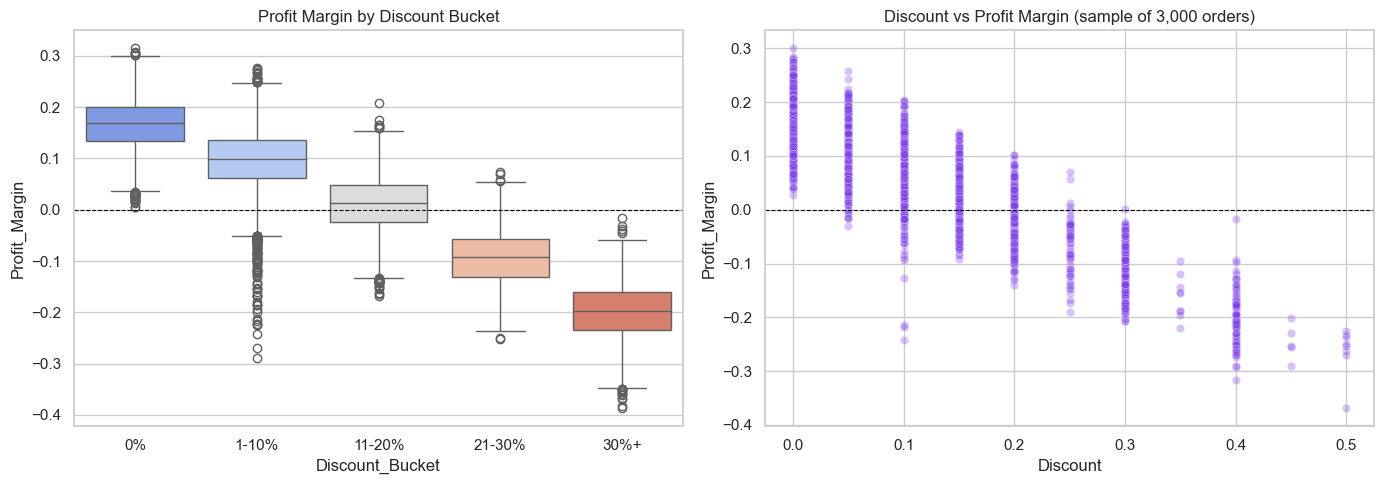

,Discount,Sales,Profit,Profit_Margin
Discount,1.000000,-0.062588,-0.434721,-0.880242
Sales,-0.062588,1.000000,0.488172,-0.097386
Profit,-0.434721,0.488172,1.000000,0.409642
Profit_Margin,-0.880242,-0.097386,0.409642,1.000000


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='Discount_Bucket', y='Profit_Margin', ax=axes[0], palette='coolwarm')
axes[0].set_title('Profit Margin by Discount Bucket')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

sample = df.sample(3000, random_state=1)
sns.scatterplot(data=sample, x='Discount', y='Profit_Margin', alpha=0.3, ax=axes[1], color='#7c3aed')
axes[1].set_title('Discount vs Profit Margin (sample of 3,000 orders)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../reports/chart_discount_vs_profit.png', bbox_inches='tight')
plt.show()

corr = df[['Discount','Sales','Profit','Profit_Margin']].corr()
corr


**Observation:** Profit margin declines steadily as discount level increases, and turns
negative on average once discounts exceed ~20-30%. This is a designed relationship in the
underlying data (mirroring realistic retail economics) and is explored further, with
concrete numbers, in the Business Insights report.

## 6. Distribution checks (Sales, Profit)

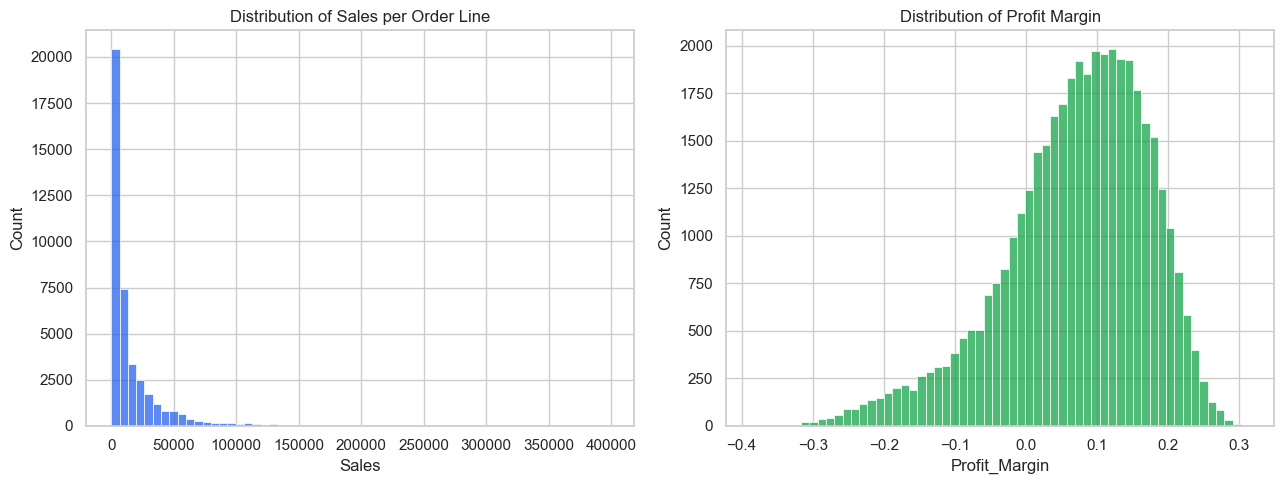

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df['Sales'], bins=60, ax=axes[0], color='#2563eb')
axes[0].set_title('Distribution of Sales per Order Line')
sns.histplot(df['Profit_Margin'], bins=60, ax=axes[1], color='#16a34a')
axes[1].set_title('Distribution of Profit Margin')
plt.tight_layout()
plt.savefig('../reports/chart_distributions.png', bbox_inches='tight')
plt.show()


## 7. Category x Region heatmap
**Question: Which category-region combinations drive the most sales?**

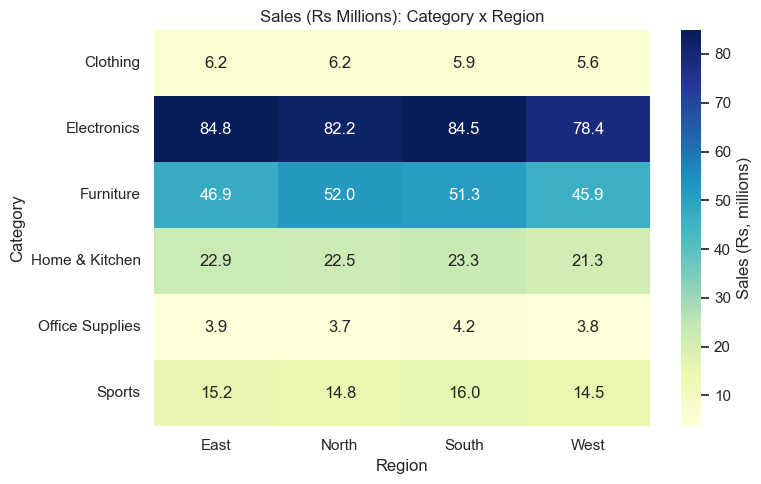

In [19]:
pivot = df.pivot_table(index='Category', columns='Region', values='Sales', aggfunc='sum')
plt.figure(figsize=(8,5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label':'Sales (Rs, millions)'})
plt.title('Sales (Rs Millions): Category x Region')
plt.tight_layout()
plt.savefig('../reports/chart_category_region_heatmap.png', bbox_inches='tight')
plt.show()


## Summary of EDA findings

- Electronics and Furniture dominate revenue; Office Supplies contributes the least.
- Profit does not track Sales proportionally - some high-revenue categories carry thin
  margins, while smaller categories are more profitable per rupee of sales.
- A meaningful share of customers are one-time buyers, indicating a retention opportunity.
- Discounting above ~20-30% is associated with order lines that are unprofitable on average.
- October-November show the clearest seasonal spike in both sales and discounting,
  consistent with festive-season promotions.

These findings are quantified with exact figures in `reports/business_insights.md`.
